# Response curves by market-activity regime

This notebook tests whether the normalized contemporaneous response varies with market activity and liquidity. The primary specification uses 4,000-event bars: event count is fixed, so duration measures the speed at which a fixed amount of transactional activity arrives. Five-minute bars provide a complementary clock-time specification: elapsed time is fixed, so event count measures transactional activity.

For both constructions, regime boundaries are equal-count quantiles. The primary curves are independently rebinned within each regime so that every regime retains its complete observed imbalance support, including economically important upper tails. Shared-edge, common-support estimates are retained only as a secondary sensitivity exercise. The logarithmic scale factor $x_{med}$ is fixed to the pooled median normalized imbalance within each bar construction. This is essential for comparing $A$, $b$, $x_0=x_{med}/b$, and the initial slope $A/x_0$ across regimes.

Regimes are contemporaneous characteristics. All differences below are conditional associations, not causal liquidity effects.

In [127]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

%matplotlib inline

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.crypto_impact.binning import (
    bin_impact_by_shared_edges,
    bin_impact_curve_with_uncertainty,
)
from src.crypto_impact.impact import add_trailing_impact_normalisation
from src.crypto_impact.monthly_eda import (
    build_fixed_event_bars,
    load_monthly_trades,
    make_time_bars,
)
from src.crypto_impact.regime_analysis import add_market_regimes, build_analysis_table
from src.crypto_impact.regression import compare_impact_models
from src.crypto_impact.shape import compare_impact_models_by_regime

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

In [150]:
DATA_DIR = PROJECT_DIR / 'data' / 'raw' / 'BTCUSDT_monthly'
FIGURE_DIR = PROJECT_DIR / 'reports' / 'figures'
TABLE_DIR = PROJECT_DIR / 'reports' / 'tables'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

EVENTS_PER_BAR = 4_000
TIME_WINDOW = '5min'
TRAILING_WINDOW = '1D'
MIN_TRAILING_BARS = 100
N_REGIMES = 5
N_BINS = 20  # Primary regime-response resolution
MIN_OBS_PER_CELL = 200
MAX_FILES = None  # set to 1 or 2 only for a smoke test

files = sorted(DATA_DIR.glob('BTCUSDT-trades-*.parquet'))
if MAX_FILES is not None:
    files = files[:MAX_FILES]
if not files:
    raise FileNotFoundError(f'No monthly parquet files found in {DATA_DIR}')
print(f'Files selected: {len(files)} ({files[0].name} to {files[-1].name})')

Files selected: 17 (BTCUSDT-trades-2025-01.parquet to BTCUSDT-trades-2026-05.parquet)


## Shared helpers

The helpers below deliberately separate construction, regime assignment, fitting, and reporting. Primary fits use independent equal-count bins within each regime and therefore preserve full observed support. The sensitivity helper uses pooled shared edges and common support. Both use a single pooled logarithmic scale factor within each bar construction; allowing every regime to choose its own median would make the reported curvature parameterization harder to compare.

In [151]:
DURATION_ORDER = [
    'very_short_duration', 'short_duration', 'medium_duration',
    'long_duration', 'very_long_duration',
]
VOLUME_ORDER = [
    'very_low_volume', 'low_volume', 'medium_volume',
    'high_volume', 'very_high_volume',
]
FLOW_RATE_ORDER = [
    'very_low_flow_rate', 'low_flow_rate', 'medium_flow_rate',
    'high_flow_rate', 'very_high_flow_rate',
]
RAW_FLOW_RATE_ORDER = [
    'very_low_raw_flow_rate', 'low_raw_flow_rate', 'medium_raw_flow_rate',
    'high_raw_flow_rate', 'very_high_raw_flow_rate',
]
TIME_ACTIVITY_ORDER = [
    'very_low_activity', 'low_activity', 'medium_activity',
    'high_activity', 'very_high_activity',
]

def prepare_normalised_analysis(bars):
    analysis = build_analysis_table(bars, horizons=())
    analysis = add_trailing_impact_normalisation(
        analysis,
        window=TRAILING_WINDOW,
        min_periods=MIN_TRAILING_BARS,
        timestamp_col='end_time',
    )
    analysis['block_day'] = pd.to_datetime(analysis['end_time'], utc=True).dt.floor('D')
    return analysis.replace([np.inf, -np.inf], np.nan)

def add_quantile_regime(data, source_col, regime_col, labels):
    result = data.copy()
    result[regime_col] = pd.qcut(result[source_col], q=len(labels), labels=labels)
    return result

def _attach_support(comparison, curves, regime_col, raw_data=None):
    support = (
        curves.groupby(regime_col, observed=True)
        .agg(
            fitted_min_x=('mean_x', 'min'),
            fitted_max_x=('mean_x', 'max'),
            bins_available=('bin_id', 'nunique'),
            observations=('n_obs', 'sum'),
        )
        .reset_index()
    )
    result = comparison.merge(support, on=regime_col, how='left')
    if raw_data is not None:
        raw = raw_data.loc[
            raw_data['normalised_imbalance'] > 0,
            [regime_col, 'normalised_imbalance'],
        ].dropna()
        observed_support = (
            raw.groupby(regime_col, observed=True)['normalised_imbalance']
            .agg(
                observed_min_x='min',
                observed_p01_x=lambda values: values.quantile(0.01),
                observed_median_x='median',
                observed_p99_x=lambda values: values.quantile(0.99),
                observed_max_x='max',
            )
            .reset_index()
        )
        result = result.merge(observed_support, on=regime_col, how='left')
    else:
        result['observed_min_x'] = result['fitted_min_x']
        result['observed_p01_x'] = np.nan
        result['observed_median_x'] = np.nan
        result['observed_p99_x'] = np.nan
        result['observed_max_x'] = result['fitted_max_x']
    return result

def fit_regime_curves(data, regime_col, regime_order):
    # Primary estimator: equal-count bins are constructed independently
    # within each regime, preserving that regime's complete observed support.
    curve_frames = []
    for regime in regime_order:
        sample = data.loc[data[regime_col] == regime]
        curve = bin_impact_curve_with_uncertainty(
            sample,
            x_col='normalised_imbalance',
            impact_col='normalised_signed_impact',
            n_bins=N_BINS,
            method='equal_count',
        )
        curve.insert(0, regime_col, regime)
        curve_frames.append(curve)
    curves = pd.concat(curve_frames, ignore_index=True)
    pooled_x_med = float(data['normalised_imbalance'].dropna().median())
    comparison, predictions, fitted_curves = compare_impact_models_by_regime(
        curves,
        regime_col=regime_col,
        regimes=regime_order,
        min_obs_per_bin=MIN_OBS_PER_CELL,
        require_common_bins=False,
        x_scale=pooled_x_med,
    )
    comparison = _attach_support(
        comparison, fitted_curves, regime_col, raw_data=data
    )
    return comparison, predictions, fitted_curves, None, pooled_x_med

def fit_common_support_regime_curves(data, regime_col, regime_order):
    # Secondary sensitivity: pooled shared edges, retaining only bins
    # represented in every regime. This deliberately targets the overlap.
    curves, edges = bin_impact_by_shared_edges(
        data,
        regime_col=regime_col,
        x_col='normalised_imbalance',
        impact_col='normalised_signed_impact',
        n_bins=N_BINS,
        min_obs_per_cell=MIN_OBS_PER_CELL,
    )
    pooled_x_med = float(data['normalised_imbalance'].dropna().median())
    comparison, predictions, common_curves = compare_impact_models_by_regime(
        curves,
        regime_col=regime_col,
        regimes=regime_order,
        min_obs_per_bin=MIN_OBS_PER_CELL,
        require_common_bins=True,
        x_scale=pooled_x_med,
    )
    comparison = _attach_support(comparison, common_curves, regime_col)
    return comparison, predictions, common_curves, edges, pooled_x_med

def logarithmic_parameter_table(comparison, regime_col, pooled_x_med):
    log_fit = comparison.loc[comparison['model'] == 'logarithmic'].set_index(regime_col)
    power_fit = comparison.loc[comparison['model'] == 'free_power'].set_index(regime_col)
    table = pd.DataFrame({
        'observed_x_med': pooled_x_med,
        'log_amplitude': log_fit['amplitude'],
        'log_curvature': log_fit['curvature'],
        'free_power_delta': power_fit['delta'],
        'log_weighted_rmse': log_fit['weighted_rmse'],
        'power_weighted_rmse': power_fit['weighted_rmse'],
        'bins_used': log_fit['bins_used'],
        'fitted_min_x': log_fit['fitted_min_x'],
        'fitted_max_x': log_fit['fitted_max_x'],
        'observed_min_x': log_fit['observed_min_x'],
        'observed_p01_x': log_fit['observed_p01_x'],
        'observed_median_x': log_fit['observed_median_x'],
        'observed_p99_x': log_fit['observed_p99_x'],
        'observed_max_x': log_fit['observed_max_x'],
        'observations': log_fit['observations'],
    })
    table['log_x0'] = pooled_x_med / table['log_curvature']
    table['initial_marginal_impact'] = table['log_amplitude'] / table['log_x0']
    table['initial_effective_liquidity'] = 1.0 / table['initial_marginal_impact']
    table['log_wrmse_improvement_pct'] = 100 * (
        table['power_weighted_rmse'] - table['log_weighted_rmse']
    ) / table['power_weighted_rmse']
    return table

def regime_characteristics(data, regime_col, regime_order):
    columns = ['duration_seconds', 'trade_count', 'gross_volume', 'flow_rate_ratio']
    available = [column for column in columns if column in data]
    return (
        data.groupby(regime_col, observed=True)[available]
        .median().reindex(regime_order)
    )

def plot_regime_response_grid(specifications, path):
    fig, axes = plt.subplots(
        2, 4, figsize=(16, 8.5), sharex=True, sharey=True,
        constrained_layout=True,
    )
    colours = plt.cm.viridis(np.linspace(0.10, 0.90, 5))
    for ax, specification in zip(axes.flat, specifications):
        title, curves, predictions, regime_col, low_to_high_order = specification
        for regime, colour in zip(low_to_high_order, colours):
            observed = curves.loc[curves[regime_col] == regime].sort_values('mean_x')
            fitted = predictions.loc[
                (predictions[regime_col] == regime)
                & (predictions['model'] == 'logarithmic')
            ].sort_values('x')
            ax.scatter(
                observed['mean_x'], observed['mean_impact'],
                s=10, color=colour, alpha=0.55, linewidths=0,
            )
            ax.plot(
                fitted['x'], fitted['predicted_impact'],
                color=colour, lw=1.5,
            )
        ax.axhline(0, color='black', lw=0.7, alpha=0.7)
        ax.set_xscale('log')
        ax.set_title(title, fontsize=10)
        ax.grid(alpha=0.15, linewidth=0.5)

    legend_ax = axes.flat[-1]
    legend_ax.axis('off')
    state_handles = [
        Line2D([0], [0], color=colour, lw=2, label=label)
        for colour, label in zip(
            colours,
            ['Q1: lowest', 'Q2', 'Q3', 'Q4', 'Q5: highest'],
        )
    ]
    legend_ax.legend(
        handles=state_handles, title='State-intensity quintile',
        loc='center', frameon=False, fontsize=10, title_fontsize=10,
    )
    legend_ax.text(
        0.5, 0.18,
        'Points: conditional means\nLines: logarithmic fits\nFull regime-specific support',
        ha='center', va='center', fontsize=9, transform=legend_ax.transAxes,
    )
    fig.suptitle('Normalized signed-impact response by market state', fontsize=14)
    fig.supxlabel('Absolute imbalance / trailing 24-hour volume')
    fig.supylabel('Mean signed return / trailing 24-hour realised volatility')
    fig.savefig(path, bbox_inches='tight')
    plt.show()

## Primary specification: duration regimes in 4,000-event bars

The established duration regimes from `add_market_regimes` are retained. Because every bar contains 4,000 events, shorter duration means faster event arrival. Duration is therefore interpreted as event speed without introducing a second classification or a second set of labels.

In [152]:
event_bars = build_fixed_event_bars(files, events_per_bar=EVENTS_PER_BAR)
event_analysis = prepare_normalised_analysis(event_bars)
event_analysis = add_market_regimes(event_analysis)
event_analysis = add_quantile_regime(
    event_analysis, 'flow_rate_btc_per_second',
    'raw_flow_rate_regime', RAW_FLOW_RATE_ORDER,
)
regime_characteristics(event_analysis, 'duration_regime', DURATION_ORDER)

,duration_seconds,trade_count,gross_volume,flow_rate_ratio
duration_regime,,,,
very_short_duration,83.127000,"4,000.000000",909.874000,4.296921
short_duration,183.341000,"4,000.000000",754.458000,1.749612
medium_duration,313.042500,"4,000.000000",688.680000,1.036187
long_duration,484.795000,"4,000.000000",627.172000,0.669507
very_long_duration,793.517000,"4,000.000000",548.242000,0.435242


In [153]:
(event_duration_comparison, event_duration_predictions, event_duration_curves,
 event_duration_edges, event_x_med) = fit_regime_curves(
    event_analysis, 'duration_regime', DURATION_ORDER
)
event_duration_parameters = logarithmic_parameter_table(
    event_duration_comparison, 'duration_regime', event_x_med
)
event_duration_parameters

,observed_x_med,log_amplitude,log_curvature,free_power_delta,log_weighted_rmse,power_weighted_rmse,bins_used,fitted_min_x,fitted_max_x,observed_min_x,observed_p01_x,observed_median_x,observed_p99_x,observed_max_x,observations,log_x0,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct
duration_regime,,,,,,,,,,,,,,,,,,,
very_short_duration,0.000540,0.050019,1.037746,0.588661,0.002175,0.002488,20,0.000023,0.005923,0.000000,0.000010,0.000606,0.006836,0.032568,22823,0.000521,96.067160,0.010409,12.574111
short_duration,0.000540,0.048777,1.049997,0.599007,0.001237,0.002849,20,0.000022,0.004695,0.000000,0.000009,0.000543,0.005553,0.030242,22789,0.000515,94.788396,0.010550,56.596414
medium_duration,0.000540,0.054150,0.863085,0.633570,0.001484,0.003010,20,0.000020,0.004214,0.000000,0.000008,0.000525,0.004973,0.028835,22681,0.000626,86.497103,0.011561,50.684143
long_duration,0.000540,0.058338,0.724896,0.663398,0.001319,0.002875,20,0.000020,0.003790,0.000000,0.000008,0.000509,0.004415,0.030552,22510,0.000745,78.265996,0.012777,54.109338
very_long_duration,0.000540,0.057465,0.643137,0.685342,0.000826,0.002300,20,0.000023,0.003547,0.000000,0.000009,0.000533,0.004095,0.016977,20773,0.000840,68.400213,0.014620,64.102444


In [154]:
event_duration_parameters.to_csv(TABLE_DIR / 'event_duration_regime_parameters.csv')

### Gross-volume regimes within 4,000-event bars

Gross volume measures how much BTC trades during the fixed 4,000 events. Compare its ordering with the duration results, while recognizing that volume and duration are correlated rather than independent state variables.

In [155]:
(event_volume_comparison, event_volume_predictions, event_volume_curves,
 event_volume_edges, _) = fit_regime_curves(
    event_analysis, 'volume_regime', VOLUME_ORDER
)
event_volume_parameters = logarithmic_parameter_table(
    event_volume_comparison, 'volume_regime', event_x_med
)
event_volume_parameters.to_csv(TABLE_DIR / 'event_volume_regime_parameters.csv')
event_volume_parameters

,observed_x_med,log_amplitude,log_curvature,free_power_delta,log_weighted_rmse,power_weighted_rmse,bins_used,fitted_min_x,fitted_max_x,observed_min_x,observed_p01_x,observed_median_x,observed_p99_x,observed_max_x,observations,log_x0,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct
volume_regime,,,,,,,,,,,,,,,,,,,
very_low_volume,0.000540,0.052042,1.000505,0.712903,0.001184,0.001459,20,0.000011,0.001662,0.000000,0.000005,0.000286,0.001978,0.004397,21753,0.000540,96.364857,0.010377,18.826619
low_volume,0.000540,0.063356,0.732518,0.724043,0.001453,0.002281,20,0.000019,0.002129,0.000000,0.000007,0.000405,0.002525,0.005570,22329,0.000738,85.892852,0.011642,36.292432
medium_volume,0.000540,0.062295,0.713735,0.697617,0.001367,0.001965,20,0.000023,0.002613,0.000000,0.000010,0.000521,0.003040,0.007012,22440,0.000757,82.288557,0.012152,30.432913
high_volume,0.000540,0.074268,0.506617,0.711189,0.001527,0.002485,20,0.000031,0.003358,0.000000,0.000012,0.000688,0.003861,0.010119,22544,0.001067,69.635616,0.014360,38.536598
very_high_volume,0.000540,0.074757,0.429140,0.636429,0.002255,0.002554,20,0.000060,0.007829,0.000000,0.000025,0.001317,0.009219,0.032568,22510,0.001259,59.374671,0.016842,11.708075


### Relative flow-rate regimes within 4,000-event bars

Raw flow rate is gross volume divided by duration and therefore combines the preceding two dimensions. The flow-rate ratio scales this quantity by the trailing 24-hour average BTC-per-second rate. It asks whether the bar's flow is unusually intense relative to prevailing market conditions. The relative measure is the regime variable; raw flow rate remains in the descriptive tables.

In [156]:
(event_flow_comparison, event_flow_predictions, event_flow_curves,
 event_flow_edges, _) = fit_regime_curves(
    event_analysis, 'flow_rate_regime', FLOW_RATE_ORDER
)
event_flow_parameters = logarithmic_parameter_table(
    event_flow_comparison, 'flow_rate_regime', event_x_med
)
event_flow_parameters.to_csv(TABLE_DIR / 'event_flow_rate_regime_parameters.csv')
event_flow_parameters

,observed_x_med,log_amplitude,log_curvature,free_power_delta,log_weighted_rmse,power_weighted_rmse,bins_used,fitted_min_x,fitted_max_x,observed_min_x,observed_p01_x,observed_median_x,observed_p99_x,observed_max_x,observations,log_x0,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct
flow_rate_regime,,,,,,,,,,,,,,,,,,,
very_low_flow_rate,0.000540,0.037498,1.359046,0.678064,0.000980,0.001732,20,0.000012,0.001531,0.000000,0.000005,0.000304,0.001745,0.004917,22316,0.000398,94.316105,0.010603,43.405467
low_flow_rate,0.000540,0.049400,0.960214,0.675720,0.001791,0.002969,20,0.000019,0.002292,0.000000,0.000007,0.000446,0.002660,0.005352,22315,0.000563,87.790220,0.011391,39.679919
medium_flow_rate,0.000540,0.049141,1.007775,0.630817,0.001217,0.002407,20,0.000024,0.003121,0.000000,0.000009,0.000550,0.003611,0.009484,22315,0.000536,91.655522,0.010910,49.421305
high_flow_rate,0.000540,0.054352,0.840488,0.622090,0.001174,0.002596,20,0.000029,0.004134,0.000000,0.000011,0.000676,0.004779,0.012763,22315,0.000643,84.546879,0.011828,54.782717
very_high_flow_rate,0.000540,0.066285,0.585587,0.605716,0.002351,0.003010,20,0.000046,0.007644,0.000000,0.000019,0.001077,0.008989,0.032568,22315,0.000923,71.837956,0.013920,21.890508


### Raw BTC-per-second flow regimes within 4,000-event bars

Raw flow rate is gross BTC volume divided by bar duration. Unlike the trailing-normalized flow-rate ratio, it does not share the trailing-volume denominator with normalized imbalance. It is included explicitly as a candidate state variable for the later tail-sensitivity comparison.

In [157]:
(event_raw_flow_comparison, event_raw_flow_predictions, event_raw_flow_curves,
 event_raw_flow_edges, _) = fit_regime_curves(
    event_analysis, 'raw_flow_rate_regime', RAW_FLOW_RATE_ORDER
)
event_raw_flow_parameters = logarithmic_parameter_table(
    event_raw_flow_comparison, 'raw_flow_rate_regime', event_x_med
)
event_raw_flow_parameters.to_csv(
    TABLE_DIR / 'event_raw_flow_rate_regime_parameters.csv'
)
event_raw_flow_parameters

,observed_x_med,log_amplitude,log_curvature,free_power_delta,log_weighted_rmse,power_weighted_rmse,bins_used,fitted_min_x,fitted_max_x,observed_min_x,observed_p01_x,observed_median_x,observed_p99_x,observed_max_x,observations,log_x0,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct
raw_flow_rate_regime,,,,,,,,,,,,,,,,,,,
very_low_raw_flow_rate,0.000540,0.054619,0.745185,0.702420,0.000878,0.001550,20,0.000018,0.002544,0.000000,0.000007,0.000425,0.003005,0.007012,20949,0.000725,75.327604,0.013275,43.395661
low_raw_flow_rate,0.000540,0.054371,0.830783,0.668356,0.001517,0.002794,20,0.000018,0.003147,0.000000,0.000007,0.000474,0.003614,0.010588,22450,0.000650,83.600192,0.011962,45.699833
medium_raw_flow_rate,0.000540,0.052762,0.886785,0.638561,0.001449,0.002751,20,0.000021,0.003660,0.000000,0.000008,0.000526,0.004316,0.016977,22653,0.000609,86.593877,0.011548,47.316595
high_raw_flow_rate,0.000540,0.050238,0.980348,0.606157,0.001350,0.002851,20,0.000023,0.004541,0.000000,0.000010,0.000579,0.005375,0.030552,22742,0.000551,91.151745,0.010971,52.652909
very_high_raw_flow_rate,0.000540,0.055161,0.825936,0.591716,0.002650,0.002659,20,0.000031,0.006981,0.000000,0.000013,0.000802,0.008276,0.032568,22782,0.000654,84.318897,0.011860,0.335594


### Dependence among event-bar regime variables

Duration, gross volume, raw flow rate and relative flow rate are related by construction and by market conditions. Spearman correlations show monotonic dependence in the underlying continuous variables. Row-normalized cross-tabulations show how much the duration, volume and relative-flow-rate classifications overlap. These diagnostics prevent the three regime families from being interpreted as independent experiments.

In [158]:
event_regime_correlations = event_analysis[[
    'duration_seconds', 'gross_volume',
    'flow_rate_btc_per_second', 'flow_rate_ratio',
]].corr(method='spearman')
event_regime_correlations.to_csv(TABLE_DIR / 'event_regime_spearman_correlations.csv')
event_regime_correlations

,duration_seconds,gross_volume,flow_rate_btc_per_second,flow_rate_ratio
duration_seconds,1.000000,-0.484722,-0.953042,-0.817160
gross_volume,-0.484722,1.000000,0.713465,0.707385
flow_rate_btc_per_second,-0.953042,0.713465,1.000000,0.890304
flow_rate_ratio,-0.817160,0.707385,0.890304,1.000000


In [159]:
duration_by_volume = pd.crosstab(
    event_analysis['duration_regime'], event_analysis['volume_regime'],
    normalize='index',
).reindex(index=DURATION_ORDER, columns=VOLUME_ORDER)
duration_by_flow = pd.crosstab(
    event_analysis['duration_regime'], event_analysis['flow_rate_regime'],
    normalize='index',
).reindex(index=DURATION_ORDER, columns=FLOW_RATE_ORDER)
duration_by_raw_flow = pd.crosstab(
    event_analysis['duration_regime'], event_analysis['raw_flow_rate_regime'],
    normalize='index',
).reindex(index=DURATION_ORDER, columns=RAW_FLOW_RATE_ORDER)
display(duration_by_volume)
display(duration_by_flow)
display(duration_by_raw_flow)

volume_regime,very_low_volume,low_volume,medium_volume,high_volume,very_high_volume
duration_regime,,,,,
very_short_duration,0.049083,0.091808,0.149950,0.249597,0.459562
short_duration,0.116197,0.167893,0.214930,0.253735,0.247245
medium_duration,0.173345,0.211193,0.229573,0.221908,0.163981
long_duration,0.250468,0.255041,0.227778,0.175471,0.091242
very_long_duration,0.410914,0.274073,0.177736,0.099299,0.037977


flow_rate_regime,very_low_flow_rate,low_flow_rate,medium_flow_rate,high_flow_rate,very_high_flow_rate
duration_regime,,,,,
very_short_duration,0.001446,0.012181,0.056040,0.221750,0.708583
short_duration,0.022072,0.093949,0.241476,0.415771,0.226732
medium_duration,0.109475,0.239011,0.355893,0.256558,0.039064
long_duration,0.285118,0.381964,0.252643,0.076455,0.003821
very_long_duration,0.619987,0.282915,0.085399,0.011505,0.000193


raw_flow_rate_regime,very_low_raw_flow_rate,low_raw_flow_rate,medium_raw_flow_rate,high_raw_flow_rate,very_high_raw_flow_rate
duration_regime,,,,,
very_short_duration,0.000000,0.000044,0.001829,0.145159,0.852968
short_duration,0.000261,0.006620,0.196899,0.653151,0.143069
medium_duration,0.008101,0.208624,0.588284,0.191159,0.003833
long_duration,0.180393,0.604198,0.205043,0.010235,0.000131
very_long_duration,0.811245,0.180523,0.007926,0.000305,0.000000


## Robustness: activity regimes in five-minute bars

Five-minute bars closely match the baseline median event-bar duration. Their duration is fixed, so event count is the primary activity variable. Gross volume supplies a quantity-based classification. Raw flow rate is proportional to gross volume when duration is fixed, so it is not fitted as a separate regime; the trailing-normalized flow-rate ratio remains informative. Monthly files can be resampled independently because the windows are aligned to the clock.

In [160]:
time_frames = []
for path in files:
    monthly = make_time_bars(load_monthly_trades(path), window=TIME_WINDOW)
    monthly['start_time'] = monthly.index
    monthly['end_time'] = monthly.index + pd.Timedelta(TIME_WINDOW)
    monthly['duration_seconds'] = pd.Timedelta(TIME_WINDOW).total_seconds()
    time_frames.append(monthly)
time_bars = pd.concat(time_frames).sort_index()
if not time_bars.index.is_unique:
    raise ValueError('Five-minute bar start times are not unique.')

time_analysis = prepare_normalised_analysis(time_bars)
time_analysis = add_quantile_regime(
    time_analysis, 'trade_count', 'time_activity_regime', TIME_ACTIVITY_ORDER
)
time_analysis = add_quantile_regime(
    time_analysis, 'gross_volume', 'time_volume_regime', VOLUME_ORDER
)
time_analysis = add_quantile_regime(
    time_analysis, 'flow_rate_ratio', 'time_flow_rate_regime', FLOW_RATE_ORDER
)
regime_characteristics(time_analysis, 'time_activity_regime', TIME_ACTIVITY_ORDER)

,duration_seconds,trade_count,gross_volume,flow_rate_ratio
time_activity_regime,,,,
very_low_activity,300.000000,"1,013.000000",112.330000,0.322994
low_activity,300.000000,"1,556.000000",206.660000,0.434096
medium_activity,300.000000,"2,155.000000",319.394000,0.588286
high_activity,300.000000,"3,119.000000",520.127000,0.860782
very_high_activity,300.000000,"6,039.000000","1,229.770000",1.822375


In [161]:
(time_activity_comparison, time_activity_predictions, time_activity_curves,
 time_activity_edges, time_x_med) = fit_regime_curves(
    time_analysis, 'time_activity_regime', TIME_ACTIVITY_ORDER
)
time_activity_parameters = logarithmic_parameter_table(
    time_activity_comparison, 'time_activity_regime', time_x_med
)
time_activity_parameters.to_csv(TABLE_DIR / 'time_bar_activity_regime_parameters.csv')
time_activity_parameters

,observed_x_med,log_amplitude,log_curvature,free_power_delta,log_weighted_rmse,power_weighted_rmse,bins_used,fitted_min_x,fitted_max_x,observed_min_x,observed_p01_x,observed_median_x,observed_p99_x,observed_max_x,observations,log_x0,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct
time_activity_regime,,,,,,,,,,,,,,,,,,,
very_low_activity,0.000358,0.027583,1.103496,0.660739,0.000596,0.001457,20,0.000009,0.001871,0.000000,0.000004,0.000215,0.002267,0.007536,29684,0.000324,85.102270,0.011751,59.135019
low_activity,0.000358,0.031845,0.994504,0.642262,0.000634,0.001672,20,0.000011,0.002369,0.000000,0.000004,0.000268,0.002804,0.027834,29687,0.000360,88.545846,0.011294,62.072468
medium_activity,0.000358,0.034593,0.979163,0.619245,0.000944,0.002272,20,0.000014,0.002830,0.000000,0.000006,0.000336,0.003350,0.018455,29709,0.000365,94.705397,0.010559,58.447233
high_activity,0.000358,0.043656,0.733536,0.614449,0.000946,0.002686,20,0.000018,0.003989,0.000000,0.000007,0.000449,0.004711,0.026574,29712,0.000488,89.535308,0.011169,64.779752
very_high_activity,0.000358,0.093631,0.278069,0.662019,0.002618,0.002600,20,0.000031,0.009376,0.000000,0.000013,0.000824,0.011371,0.071292,29713,0.001286,72.794484,0.013737,-0.694526


### Gross-volume regimes in five-minute bars

Gross volume measures quantity traded within the fixed clock-time window. It is reported separately from event count even though the two activity measures are correlated.

In [162]:
(time_volume_comparison, time_volume_predictions, time_volume_curves,
 time_volume_edges, _) = fit_regime_curves(
    time_analysis, 'time_volume_regime', VOLUME_ORDER
)
time_volume_parameters = logarithmic_parameter_table(
    time_volume_comparison, 'time_volume_regime', time_x_med
)
time_volume_parameters.to_csv(TABLE_DIR / 'time_bar_volume_regime_parameters.csv')
time_volume_parameters

,observed_x_med,log_amplitude,log_curvature,free_power_delta,log_weighted_rmse,power_weighted_rmse,bins_used,fitted_min_x,fitted_max_x,observed_min_x,observed_p01_x,observed_median_x,observed_p99_x,observed_max_x,observations,log_x0,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct
time_volume_regime,,,,,,,,,,,,,,,,,,,
very_low_volume,0.000358,0.038159,0.846268,0.740425,0.000471,0.000943,20,0.000008,0.001209,0.000000,0.000003,0.000173,0.001441,0.004338,29676,0.000423,90.288973,0.011076,50.061716
low_volume,0.000358,0.035762,0.899058,0.685090,0.000874,0.001478,20,0.000011,0.001658,0.000000,0.000004,0.000247,0.001958,0.004421,29690,0.000398,89.896161,0.011124,40.884320
medium_volume,0.000358,0.037378,0.840465,0.659154,0.000942,0.002071,20,0.000016,0.002216,0.000000,0.000007,0.000348,0.002669,0.007996,29706,0.000426,87.834325,0.011385,54.506968
high_volume,0.000358,0.045576,0.635740,0.641148,0.000839,0.002375,20,0.000022,0.003171,0.000000,0.000008,0.000512,0.003678,0.015634,29714,0.000563,81.009853,0.012344,64.681407
very_high_volume,0.000358,0.091395,0.261229,0.656115,0.003031,0.002526,20,0.000043,0.009847,0.000000,0.000018,0.001055,0.011863,0.071292,29719,0.001369,66.753223,0.014981,-19.986949


### Relative flow-rate regimes in five-minute bars

With fixed duration, raw BTC-per-second flow is simply gross volume divided by 300 seconds and would reproduce the volume ranking. The relative flow-rate ratio instead compares that flow with the trailing 24-hour market rate, providing a state-relative robustness check.

In [163]:
(time_flow_comparison, time_flow_predictions, time_flow_curves,
 time_flow_edges, _) = fit_regime_curves(
    time_analysis, 'time_flow_rate_regime', FLOW_RATE_ORDER
)
time_flow_parameters = logarithmic_parameter_table(
    time_flow_comparison, 'time_flow_rate_regime', time_x_med
)
time_flow_parameters.to_csv(TABLE_DIR / 'time_bar_flow_rate_regime_parameters.csv')
time_flow_parameters

,observed_x_med,log_amplitude,log_curvature,free_power_delta,log_weighted_rmse,power_weighted_rmse,bins_used,fitted_min_x,fitted_max_x,observed_min_x,observed_p01_x,observed_median_x,observed_p99_x,observed_max_x,observations,log_x0,initial_marginal_impact,initial_effective_liquidity,log_wrmse_improvement_pct
time_flow_rate_regime,,,,,,,,,,,,,,,,,,,
very_low_flow_rate,0.000358,0.037811,0.949267,0.803499,0.000478,0.000638,20,0.000006,0.000514,0.000000,0.000002,0.000130,0.000575,0.000911,29701,0.000377,100.354209,0.009965,25.011739
low_flow_rate,0.000358,0.044794,0.704590,0.778338,0.000925,0.001370,20,0.000012,0.000841,0.000000,0.000005,0.000248,0.000932,0.001501,29701,0.000508,88.243027,0.011332,32.451533
medium_flow_rate,0.000358,0.043225,0.691615,0.719691,0.001201,0.001929,20,0.000019,0.001290,0.000000,0.000008,0.000385,0.001426,0.002197,29701,0.000517,83.583650,0.011964,37.763792
high_flow_rate,0.000358,0.045253,0.633964,0.665215,0.001733,0.002963,20,0.000028,0.002119,0.000000,0.000011,0.000613,0.002348,0.003748,29701,0.000564,80.212673,0.012467,41.505128
very_high_flow_rate,0.000358,0.103395,0.200499,0.673403,0.003096,0.002950,20,0.000063,0.009929,0.000000,0.000026,0.001378,0.011896,0.071292,29701,0.001784,57.961200,0.017253,-4.967576


## Response curves across market states

The seven headline response comparisons are presented on one grid because their qualitative message is similar. Colors always run from the lowest- to the highest-intensity quintile; duration labels are therefore reversed and interpreted as event speed. Points are full-support conditional means and lines are logarithmic fits. Per-bin uncertainty remains available in the underlying curve tables and is omitted here to keep the comparison legible.

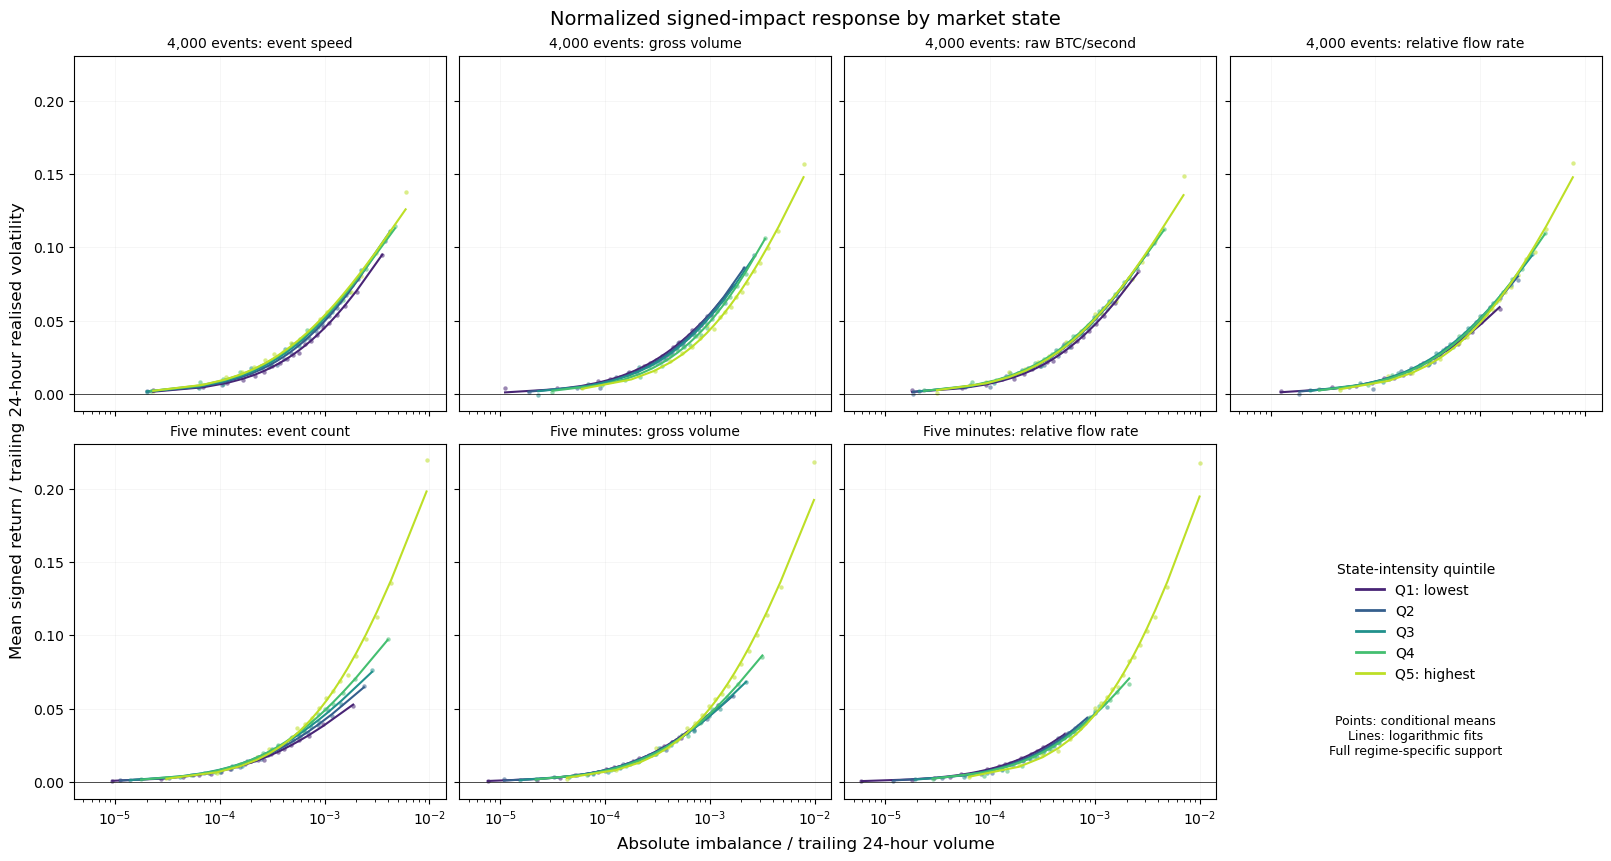

In [164]:
response_grid_specs = [
    (
        '4,000 events: event speed',
        event_duration_curves, event_duration_predictions,
        'duration_regime', list(reversed(DURATION_ORDER)),
    ),
    (
        '4,000 events: gross volume',
        event_volume_curves, event_volume_predictions,
        'volume_regime', VOLUME_ORDER,
    ),
    (
        '4,000 events: raw BTC/second',
        event_raw_flow_curves, event_raw_flow_predictions,
        'raw_flow_rate_regime', RAW_FLOW_RATE_ORDER,
    ),
    (
        '4,000 events: relative flow rate',
        event_flow_curves, event_flow_predictions,
        'flow_rate_regime', FLOW_RATE_ORDER,
    ),
    (
        'Five minutes: event count',
        time_activity_curves, time_activity_predictions,
        'time_activity_regime', TIME_ACTIVITY_ORDER,
    ),
    (
        'Five minutes: gross volume',
        time_volume_curves, time_volume_predictions,
        'time_volume_regime', VOLUME_ORDER,
    ),
    (
        'Five minutes: relative flow rate',
        time_flow_curves, time_flow_predictions,
        'time_flow_rate_regime', FLOW_RATE_ORDER,
    ),
]
plot_regime_response_grid(
    response_grid_specs,
    FIGURE_DIR / '10_regime_response_curves_grid.pdf',
)

### Dependence among five-minute regime variables

The same dependence check is repeated for the clock-time construction. Raw flow rate should be perfectly rank-correlated with gross volume because every bar lasts 300 seconds; this is why it is not treated as a separate regime family.

In [165]:
time_regime_correlations = time_analysis[[
    'trade_count', 'gross_volume',
    'flow_rate_btc_per_second', 'flow_rate_ratio',
]].corr(method='spearman')
time_regime_correlations.to_csv(TABLE_DIR / 'time_regime_spearman_correlations.csv')
activity_by_volume = pd.crosstab(
    time_analysis['time_activity_regime'], time_analysis['time_volume_regime'],
    normalize='index',
).reindex(index=TIME_ACTIVITY_ORDER, columns=VOLUME_ORDER)
activity_by_flow = pd.crosstab(
    time_analysis['time_activity_regime'], time_analysis['time_flow_rate_regime'],
    normalize='index',
).reindex(index=TIME_ACTIVITY_ORDER, columns=FLOW_RATE_ORDER)
display(time_regime_correlations)
display(activity_by_volume)
display(activity_by_flow)

,trade_count,gross_volume,flow_rate_btc_per_second,flow_rate_ratio
trade_count,1.000000,0.924072,0.924072,0.705221
gross_volume,0.924072,1.000000,1.000000,0.819094
flow_rate_btc_per_second,0.924072,1.000000,1.000000,0.819094
flow_rate_ratio,0.705221,0.819094,0.819094,1.000000


time_volume_regime,very_low_volume,low_volume,medium_volume,high_volume,very_high_volume
time_activity_regime,,,,,
very_low_activity,0.765657,0.202407,0.029314,0.002622,0.000000
low_activity,0.212610,0.521897,0.230653,0.033325,0.001515
medium_activity,0.020155,0.250008,0.497291,0.218984,0.013560
high_activity,0.000976,0.025640,0.236179,0.582153,0.155052
very_high_activity,0.000034,0.000135,0.006697,0.163026,0.830108


time_flow_rate_regime,very_low_flow_rate,low_flow_rate,medium_flow_rate,high_flow_rate,very_high_flow_rate
time_activity_regime,,,,,
very_low_activity,0.516137,0.262431,0.142198,0.065692,0.013543
low_activity,0.296797,0.319500,0.225216,0.122512,0.035975
medium_activity,0.132418,0.260998,0.305362,0.222424,0.078798
high_activity,0.049643,0.130688,0.248990,0.359686,0.210992
very_high_activity,0.005385,0.026554,0.078215,0.229496,0.660351


## High-imbalance resolution and state-variable selection

Twenty bins describe broad regime curves but compress the upper 5% into one mean. This section increases resolution without deleting observations, then fits a logarithmic response on the lower 95% and evaluates it out of sample in predetermined tail intervals. Positive tail excess means observed impact lies above the central logarithmic response. It is consistent with net replenishment failing to keep pace, but transaction data cannot separately identify liquidity arrival and cancellation rates.

Candidate state variables are ranked using the high-minus-low contrast in 99th-percentile tail excess and its monotonicity across quintiles. Raw BTC-per-second flow is included separately from the trailing-normalized flow-rate ratio. The ranking is descriptive evidence for choosing a moderator in a later latent-liquidity model, not a structural estimate of order arrival or cancellation.

In [166]:
RESOLUTION_BIN_COUNTS = [20, 40, 60, 80, 100]
TAIL_QUANTILE_EDGES = [0.0, 0.50, 0.75, 0.90, 0.95, 0.975, 0.99, 0.995, 1.0]
CENTRAL_QUANTILE = 0.95
TAIL_COMPARISON_QUANTILE = 0.99

def fit_resolution_grid(data, regime_col, regime_order):
    pooled_x_med = float(data['normalised_imbalance'].dropna().median())
    rows = []
    for regime in regime_order:
        sample = data.loc[data[regime_col] == regime]
        for n_bins in RESOLUTION_BIN_COUNTS:
            curve = bin_impact_curve_with_uncertainty(
                sample, x_col='normalised_imbalance',
                impact_col='normalised_signed_impact',
                n_bins=n_bins, method='equal_count',
            ).sort_values('mean_x')
            min_bin_count = max(50, int(0.8 * len(sample) / n_bins))
            comparison, predictions = compare_impact_models(
                curve, min_obs_per_bin=min_bin_count, x_scale=pooled_x_med
            )
            fitted = comparison.set_index('model')
            log_prediction = (
                predictions.loc[predictions['model'] == 'logarithmic']
                .sort_values('x')['predicted_impact'].iloc[-1]
            )
            final_bin = curve.iloc[-1]
            rows.append({
                regime_col: regime, 'regime': regime, 'n_bins': n_bins,
                'free_power_delta': fitted.loc['free_power', 'delta'],
                'log_weighted_rmse': fitted.loc['logarithmic', 'weighted_rmse'],
                'power_weighted_rmse': fitted.loc['free_power', 'weighted_rmse'],
                'log_wrmse_improvement_pct': 100 * (
                    fitted.loc['free_power', 'weighted_rmse']
                    - fitted.loc['logarithmic', 'weighted_rmse']
                ) / fitted.loc['free_power', 'weighted_rmse'],
                'final_bin_mean_x': final_bin['mean_x'],
                'final_bin_mean_impact': final_bin['mean_impact'],
                'final_bin_log_excess': final_bin['mean_impact'] - log_prediction,
                'final_bin_standard_error': final_bin['standard_error'],
                'final_bin_n': int(final_bin['n_obs']),
            })
    return pd.DataFrame(rows)

def central_log_tail_diagnostics(data, regime_col, regime_order):
    pooled_x_med = float(data['normalised_imbalance'].dropna().median())
    rows = []
    for regime in regime_order:
        sample = data.loc[
            data[regime_col] == regime,
            ['normalised_imbalance', 'normalised_signed_impact', 'block_day'],
        ].replace([np.inf, -np.inf], np.nan).dropna()
        sample = sample.loc[sample['normalised_imbalance'] > 0].copy()
        central_limit = sample['normalised_imbalance'].quantile(CENTRAL_QUANTILE)
        central = sample.loc[sample['normalised_imbalance'] <= central_limit]
        central_curve = bin_impact_curve_with_uncertainty(
            central, x_col='normalised_imbalance',
            impact_col='normalised_signed_impact',
            n_bins=60, method='equal_count',
        )
        comparison, _ = compare_impact_models(
            central_curve, min_obs_per_bin=100, x_scale=pooled_x_med
        )
        log_fit = comparison.set_index('model').loc['logarithmic']
        sample['central_log_prediction'] = log_fit['amplitude'] * np.log1p(
            log_fit['curvature'] * sample['normalised_imbalance'] / pooled_x_med
        )
        sample['tail_excess'] = (
            sample['normalised_signed_impact'] - sample['central_log_prediction']
        )
        sample['tail_bin'] = pd.qcut(
            sample['normalised_imbalance'], q=TAIL_QUANTILE_EDGES,
            labels=False, duplicates='drop',
        )
        grouped = sample.groupby('tail_bin', observed=True)
        for bin_id, group in grouped:
            bin_id = int(bin_id)
            excess_se = group['tail_excess'].std() / np.sqrt(len(group))
            rows.append({
                regime_col: regime, 'regime': regime, 'tail_bin': bin_id,
                'quantile_left': TAIL_QUANTILE_EDGES[bin_id],
                'quantile_right': TAIL_QUANTILE_EDGES[bin_id + 1],
                'mean_x': group['normalised_imbalance'].mean(),
                'min_x': group['normalised_imbalance'].min(),
                'max_x': group['normalised_imbalance'].max(),
                'mean_impact': group['normalised_signed_impact'].mean(),
                'median_impact': group['normalised_signed_impact'].median(),
                'mean_central_log_prediction': group['central_log_prediction'].mean(),
                'mean_tail_excess': group['tail_excess'].mean(),
                'tail_excess_standard_error': excess_se,
                'standardized_tail_excess': group['tail_excess'].mean() / excess_se,
                'n_obs': len(group),
                'n_days': group['block_day'].nunique(),
                'central_fit_limit_x': central_limit,
            })
    return pd.DataFrame(rows)

def summarize_state_sensitivity(tail_diagnostics, regime_col, low_to_high_order):
    tail = tail_diagnostics.loc[
        tail_diagnostics['quantile_left'] >= TAIL_COMPARISON_QUANTILE
    ].copy()
    by_regime = (
        tail.assign(weighted_excess=tail['mean_tail_excess'] * tail['n_obs'])
        .groupby(regime_col, observed=True)
        .agg(weighted_excess=('weighted_excess', 'sum'), n_obs=('n_obs', 'sum'))
    )
    by_regime['tail_excess'] = by_regime['weighted_excess'] / by_regime['n_obs']
    ordered = by_regime['tail_excess'].reindex(low_to_high_order)
    return {
        'low_state_tail_excess': ordered.iloc[0],
        'high_state_tail_excess': ordered.iloc[-1],
        'high_minus_low_tail_excess': ordered.iloc[-1] - ordered.iloc[0],
        'tail_excess_range': ordered.max() - ordered.min(),
        'rank_correlation': ordered.corr(
            pd.Series(np.arange(len(ordered)), index=ordered.index), method='spearman'
        ),
    }

In [167]:
state_specs = {
    'event_speed': (event_analysis, 'duration_regime', list(reversed(DURATION_ORDER))),
    'event_gross_volume': (event_analysis, 'volume_regime', VOLUME_ORDER),
    'event_raw_btc_per_second': (event_analysis, 'raw_flow_rate_regime', RAW_FLOW_RATE_ORDER),
    'event_relative_flow_rate': (event_analysis, 'flow_rate_regime', FLOW_RATE_ORDER),
    'time_event_count': (time_analysis, 'time_activity_regime', TIME_ACTIVITY_ORDER),
    'time_gross_volume': (time_analysis, 'time_volume_regime', VOLUME_ORDER),
    'time_relative_flow_rate': (time_analysis, 'time_flow_rate_regime', FLOW_RATE_ORDER),
}
resolution_frames = []
tail_frames = []
sensitivity_rows = []
for state_variable, (sample, regime_col, low_to_high_order) in state_specs.items():
    resolution = fit_resolution_grid(sample, regime_col, low_to_high_order)
    resolution.insert(0, 'state_variable', state_variable)
    resolution_frames.append(resolution)
    tail = central_log_tail_diagnostics(sample, regime_col, low_to_high_order)
    tail.insert(0, 'state_variable', state_variable)
    tail_frames.append(tail)
    sensitivity_rows.append({
        'state_variable': state_variable,
        **summarize_state_sensitivity(tail, regime_col, low_to_high_order),
    })
resolution_stability = pd.concat(resolution_frames, ignore_index=True)
tail_diagnostics = pd.concat(tail_frames, ignore_index=True)
state_sensitivity = (
    pd.DataFrame(sensitivity_rows)
    .sort_values(['high_minus_low_tail_excess', 'rank_correlation'], ascending=False)
    .reset_index(drop=True)
)
resolution_stability.to_csv(TABLE_DIR / 'regime_tail_bin_resolution_stability.csv', index=False)
tail_diagnostics.to_csv(TABLE_DIR / 'regime_central_log_tail_diagnostics.csv', index=False)
state_sensitivity.to_csv(TABLE_DIR / 'regime_state_variable_tail_sensitivity.csv', index=False)
state_sensitivity

,state_variable,low_state_tail_excess,high_state_tail_excess,high_minus_low_tail_excess,tail_excess_range,rank_correlation
0,time_gross_volume,0.004847,0.139987,0.135140,0.136382,0.400000
1,time_event_count,0.001769,0.135728,0.133959,0.133959,1.000000
2,time_relative_flow_rate,-0.000182,0.133702,0.133885,0.147620,0.000000
3,event_speed,0.004580,0.067334,0.062754,0.064726,0.900000
4,event_relative_flow_rate,-0.003950,0.047653,0.051603,0.052233,0.900000
5,event_raw_btc_per_second,0.010828,0.059499,0.048671,0.054935,0.800000
6,event_gross_volume,0.012459,0.042981,0.030522,0.042297,0.900000


### Day-block uncertainty for state sensitivity

The state-variable ranking is checked by resampling complete UTC days. Each bootstrap sample refits the central logarithmic curve separately in the lowest- and highest-intensity quintiles and recomputes mean excess above the within-state 99th percentile. The confidence interval concerns the high-minus-low tail-excess contrast.

In [168]:
N_TAIL_BOOTSTRAP = 100

def _tail_excess_for_sample(sample, pooled_x_med):
    sample = sample[[
        'normalised_imbalance', 'normalised_signed_impact'
    ]].replace([np.inf, -np.inf], np.nan).dropna()
    sample = sample.loc[sample['normalised_imbalance'] > 0].copy()
    central_limit = sample['normalised_imbalance'].quantile(CENTRAL_QUANTILE)
    tail_limit = sample['normalised_imbalance'].quantile(TAIL_COMPARISON_QUANTILE)
    central = sample.loc[sample['normalised_imbalance'] <= central_limit]
    curve = bin_impact_curve_with_uncertainty(
        central, x_col='normalised_imbalance',
        impact_col='normalised_signed_impact',
        n_bins=40, method='equal_count',
    )
    min_bin_count = max(30, int(0.5 * len(central) / 40))
    comparison, _ = compare_impact_models(
        curve, min_obs_per_bin=min_bin_count, x_scale=pooled_x_med
    )
    log_fit = comparison.set_index('model').loc['logarithmic']
    tail = sample.loc[sample['normalised_imbalance'] >= tail_limit]
    prediction = log_fit['amplitude'] * np.log1p(
        log_fit['curvature'] * tail['normalised_imbalance'] / pooled_x_med
    )
    return float((tail['normalised_signed_impact'] - prediction).mean())

def block_bootstrap_state_contrast(
    data, regime_col, low_regime, high_regime,
    n_bootstrap=N_TAIL_BOOTSTRAP, random_state=0,
):
    columns = [
        regime_col, 'block_day', 'normalised_imbalance',
        'normalised_signed_impact',
    ]
    sample = data.loc[data[regime_col].isin([low_regime, high_regime]), columns]
    sample = sample.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    day_indices = {
        day: group.index.to_numpy()
        for day, group in sample.groupby('block_day', observed=True)
    }
    days = np.asarray(list(day_indices), dtype=object)
    pooled_x_med = float(data['normalised_imbalance'].dropna().median())
    rng = np.random.default_rng(random_state)
    rows = []
    for bootstrap_sample in range(n_bootstrap):
        sampled_days = rng.choice(days, size=len(days), replace=True)
        indices = np.concatenate([day_indices[day] for day in sampled_days])
        draw = sample.iloc[indices]
        try:
            low_excess = _tail_excess_for_sample(
                draw.loc[draw[regime_col] == low_regime], pooled_x_med
            )
            high_excess = _tail_excess_for_sample(
                draw.loc[draw[regime_col] == high_regime], pooled_x_med
            )
        except (RuntimeError, ValueError):
            continue
        rows.append({
            'bootstrap_sample': bootstrap_sample,
            'low_state_tail_excess': low_excess,
            'high_state_tail_excess': high_excess,
            'high_minus_low_tail_excess': high_excess - low_excess,
        })
    return pd.DataFrame(rows)

bootstrap_frames = []
bootstrap_summary_rows = []
for state_number, (state_variable, (sample, regime_col, order)) in enumerate(state_specs.items()):
    draws = block_bootstrap_state_contrast(
        sample, regime_col, order[0], order[-1],
        random_state=1_000 + state_number,
    )
    draws.insert(0, 'state_variable', state_variable)
    bootstrap_frames.append(draws)
    contrast = draws['high_minus_low_tail_excess']
    bootstrap_summary_rows.append({
        'state_variable': state_variable,
        'bootstrap_samples': len(draws),
        'bootstrap_contrast_mean': contrast.mean(),
        'bootstrap_contrast_p025': contrast.quantile(0.025),
        'bootstrap_contrast_p975': contrast.quantile(0.975),
        'probability_positive_contrast': (contrast > 0).mean(),
    })
tail_sensitivity_bootstrap = pd.concat(bootstrap_frames, ignore_index=True)
bootstrap_summary = pd.DataFrame(bootstrap_summary_rows)
state_sensitivity = (
    state_sensitivity.merge(bootstrap_summary, on='state_variable', how='left')
    .sort_values(
        ['probability_positive_contrast', 'bootstrap_contrast_mean'],
        ascending=False,
    )
    .reset_index(drop=True)
)
tail_sensitivity_bootstrap.to_csv(
    TABLE_DIR / 'regime_state_variable_tail_sensitivity_bootstrap.csv', index=False
)
state_sensitivity.to_csv(
    TABLE_DIR / 'regime_state_variable_tail_sensitivity.csv', index=False
)
state_sensitivity

,state_variable,low_state_tail_excess,high_state_tail_excess,high_minus_low_tail_excess,tail_excess_range,rank_correlation,bootstrap_samples,bootstrap_contrast_mean,bootstrap_contrast_p025,bootstrap_contrast_p975,probability_positive_contrast
0,time_relative_flow_rate,-0.000182,0.133702,0.133885,0.147620,0.000000,100,0.137305,0.101421,0.166799,1.000000
1,time_event_count,0.001769,0.135728,0.133959,0.133959,1.000000,100,0.135148,0.110416,0.173001,1.000000
2,time_gross_volume,0.004847,0.139987,0.135140,0.136382,0.400000,100,0.132023,0.096033,0.168750,1.000000
3,event_speed,0.004580,0.067334,0.062754,0.064726,0.900000,100,0.061967,0.042332,0.082283,1.000000
4,event_relative_flow_rate,-0.003950,0.047653,0.051603,0.052233,0.900000,100,0.049902,0.029830,0.068401,1.000000
5,event_raw_btc_per_second,0.010828,0.059499,0.048671,0.054935,0.800000,100,0.045269,0.026552,0.062549,1.000000
6,event_gross_volume,0.012459,0.042981,0.030522,0.042297,0.900000,100,0.030224,0.013242,0.047413,1.000000


### Tail-detail plots

The first plot checks whether exponent and model ranking stabilize as smoothing is reduced. The second plots the upper 10% against the central logarithmic extrapolation. Observation and UTC-day counts remain available in `tail_diagnostics`; no tail observation is deleted.

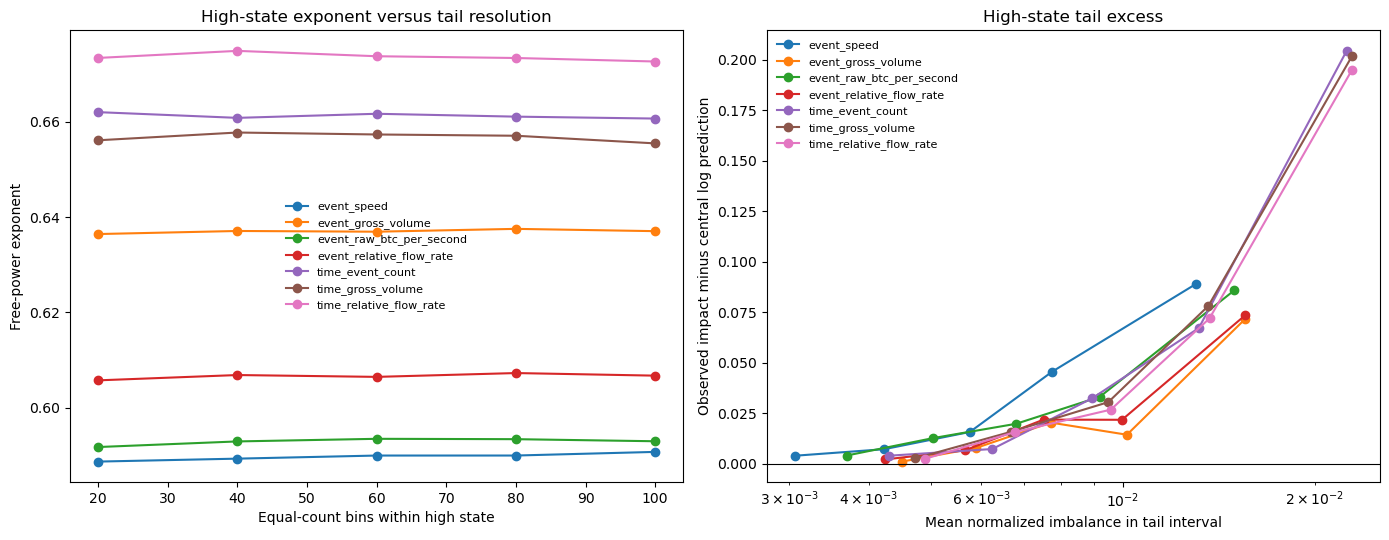

In [169]:
high_state_labels = {name: order[-1] for name, (_, _, order) in state_specs.items()}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for state_variable, high_regime in high_state_labels.items():
    group = resolution_stability.loc[
        (resolution_stability['state_variable'] == state_variable)
        & (resolution_stability['regime'] == high_regime)
    ]
    axes[0].plot(group['n_bins'], group['free_power_delta'], marker='o', label=state_variable)
axes[0].set_xlabel('Equal-count bins within high state')
axes[0].set_ylabel('Free-power exponent')
axes[0].set_title('High-state exponent versus tail resolution')

for state_variable, high_regime in high_state_labels.items():
    group = tail_diagnostics.loc[
        (tail_diagnostics['state_variable'] == state_variable)
        & (tail_diagnostics['regime'] == high_regime)
        & (tail_diagnostics['quantile_left'] >= 0.90)
    ].sort_values('mean_x')
    axes[1].plot(group['mean_x'], group['mean_tail_excess'], marker='o', label=state_variable)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xscale('log')
axes[1].set_xlabel('Mean normalized imbalance in tail interval')
axes[1].set_ylabel('Observed impact minus central log prediction')
axes[1].set_title('High-state tail excess')
axes[0].legend(frameon=False, fontsize=8)
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / '16_high_state_tail_resolution_and_excess.pdf', bbox_inches='tight')
plt.show()

### Interpretation for a later arrival/cancellation model

Prefer a state variable only if it combines a sizeable high-minus-low tail-excess contrast, a monotonic quintile ordering, stable results from 20 to 100 bins, and agreement between event-time and five-minute robustness measures. Raw BTC-per-second flow is not selected in advance. If it performs best, it is the leading moderator for a reduced-form net-liquidity mechanism. Separating liquidity arrival from cancellation would still require order-book event data or additional identifying restrictions; trade-only curves identify their net effect.

## Common-support sensitivity

The headline fits above retain each regime's full observed support. This secondary exercise returns to pooled shared edges and keeps only bins represented in every regime. It answers a narrower question about the central overlap and must not replace the full-support results. `support_log_span_fraction` reports how much of each primary regime's fitted log-$x$ span remains.

In [170]:
sensitivity_specs = {
    'event_duration': (event_analysis, 'duration_regime', DURATION_ORDER, event_duration_parameters),
    'event_volume': (event_analysis, 'volume_regime', VOLUME_ORDER, event_volume_parameters),
    'event_relative_flow_rate': (event_analysis, 'flow_rate_regime', FLOW_RATE_ORDER, event_flow_parameters),
    'event_raw_flow_rate': (event_analysis, 'raw_flow_rate_regime', RAW_FLOW_RATE_ORDER, event_raw_flow_parameters),
    'time_activity': (time_analysis, 'time_activity_regime', TIME_ACTIVITY_ORDER, time_activity_parameters),
    'time_volume': (time_analysis, 'time_volume_regime', VOLUME_ORDER, time_volume_parameters),
    'time_relative_flow_rate': (time_analysis, 'time_flow_rate_regime', FLOW_RATE_ORDER, time_flow_parameters),
}
common_support_frames = {}
for name, (sample, regime_col, regime_order, primary) in sensitivity_specs.items():
    comparison, _, curves, _, x_med = fit_common_support_regime_curves(
        sample, regime_col, regime_order
    )
    sensitivity = logarithmic_parameter_table(comparison, regime_col, x_med)
    sensitivity['support_log_span_fraction'] = (
        np.log(sensitivity['fitted_max_x'] / sensitivity['fitted_min_x'])
        / np.log(primary['fitted_max_x'] / primary['fitted_min_x'])
    )
    common_support_frames[name] = sensitivity
common_support_results = pd.concat(
    common_support_frames, names=['specification', 'regime']
)
common_support_results.to_csv(TABLE_DIR / 'regime_response_common_support_sensitivity.csv')
common_support_results

observed_x_med  \
specification            regime                                    
event_duration           very_short_duration            0.000540   
                         short_duration                 0.000540   
                         medium_duration                0.000540   
                         long_duration                  0.000540   
                         very_long_duration             0.000540   
event_volume             very_low_volume                0.000540   
                         low_volume                     0.000540   
                         medium_volume                  0.000540   
                         high_volume                    0.000540   
                         very_high_volume               0.000540   
event_relative_flow_rate very_low_flow_rate             0.000540   
                         low_flow_rate                  0.000540   
                         medium_flow_rate               0.000540   
                         high_flow_rate                 0.000540   
                         very_high_flow_rate            0.000540   
event_raw_flow_rate      very_low_raw_flow_rate         0.000540   
                         low_raw_flow_rate              0.000540   
                         medium_raw_flow_rate           0.000540   
                         high_raw_flow_rate             0.000540   
                         very_high_raw_flow_rate        0.000540   
time_activity            very_low_activity              0.000358   
                         low_activity                   0.000358   
                         medium_activity                0.000358   
                         high_activity                  0.000358   
                         very_high_activity             0.000358   
time_volume              very_low_volume                0.000358   
                         low_volume                     0.000358   
                         medium_volume                  0.000358   
                         high_volume                    0.000358   
                         very_high_volume               0.000358   
time_relative_flow_rate  very_low_flow_rate             0.000358   
                         low_flow_rate                  0.000358   
                         medium_flow_rate               0.000358   
                         high_flow_rate                 0.000358   
                         very_high_flow_rate            0.000358   

                                                  log_amplitude  \
specification            regime                                   
event_duration           very_short_duration           0.048686   
                         short_duration                0.048622   
                         medium_duration               0.055087   
                         long_duration                 0.059296   
                         very_long_duration            0.058264   
event_volume             very_low_volume               0.050534   
                         low_volume                    0.066798   
                         medium_volume                 0.058506   
                         high_volume                   0.075935   
                         very_high_volume              0.058114   
event_relative_flow_rate very_low_flow_rate            0.038548   
                         low_flow_rate                 0.053938   
                         medium_flow_rate              0.048397   
                         high_flow_rate                0.054593   
                         very_high_flow_rate           0.054390   
event_raw_flow_rate      very_low_raw_flow_rate        0.057129   
                         low_raw_flow_rate             0.055140   
                         medium_raw_flow_rate          0.053618   
                         high_raw_flow_rate            0.050646   
                         very_high_raw_flow_rate       0.052111   
time_activity            very_low_activity             0.02

## Cross-construction comparison and interpretation checklist

The event-time and clock-time regime labels do not identify the same objects, so compare ordering and broad separation rather than matching coefficients regime by regime. Focus on: (1) whether longer-duration event bars have lower fitted response and larger $x_0/A$; (2) whether five-minute bars with fewer events show the corresponding ordering; (3) whether gross-volume and relative-flow-rate results agree across constructions; (4) whether conclusions persist in the raw conditional means rather than depending only on weighted RMSE; (5) whether separation is broad or concentrated in the final imbalance bins; and (6) how strongly the regime variables overlap. Do not interpret $x_0/A$ as observed depth: it is implied effective liquidity under the logarithmic mechanism.

In [171]:
cross_construction = pd.concat(
    {
        'event_duration': event_duration_parameters,
        'event_volume': event_volume_parameters,
        'event_relative_flow_rate': event_flow_parameters,
        'event_raw_flow_rate': event_raw_flow_parameters,
        'time_activity': time_activity_parameters,
        'time_volume': time_volume_parameters,
        'time_relative_flow_rate': time_flow_parameters,
    },
    names=['specification', 'regime'],
)
cross_construction.to_csv(TABLE_DIR / 'regime_response_parameters.csv')
cross_construction

observed_x_med  \
specification            regime                                    
event_duration           very_short_duration            0.000540   
                         short_duration                 0.000540   
                         medium_duration                0.000540   
                         long_duration                  0.000540   
                         very_long_duration             0.000540   
event_volume             very_low_volume                0.000540   
                         low_volume                     0.000540   
                         medium_volume                  0.000540   
                         high_volume                    0.000540   
                         very_high_volume               0.000540   
event_relative_flow_rate very_low_flow_rate             0.000540   
                         low_flow_rate                  0.000540   
                         medium_flow_rate               0.000540   
                         high_flow_rate                 0.000540   
                         very_high_flow_rate            0.000540   
event_raw_flow_rate      very_low_raw_flow_rate         0.000540   
                         low_raw_flow_rate              0.000540   
                         medium_raw_flow_rate           0.000540   
                         high_raw_flow_rate             0.000540   
                         very_high_raw_flow_rate        0.000540   
time_activity            very_low_activity              0.000358   
                         low_activity                   0.000358   
                         medium_activity                0.000358   
                         high_activity                  0.000358   
                         very_high_activity             0.000358   
time_volume              very_low_volume                0.000358   
                         low_volume                     0.000358   
                         medium_volume                  0.000358   
                         high_volume                    0.000358   
                         very_high_volume               0.000358   
time_relative_flow_rate  very_low_flow_rate             0.000358   
                         low_flow_rate                  0.000358   
                         medium_flow_rate               0.000358   
                         high_flow_rate                 0.000358   
                         very_high_flow_rate            0.000358   

                                                  log_amplitude  \
specification            regime                                   
event_duration           very_short_duration           0.050019   
                         short_duration                0.048777   
                         medium_duration               0.054150   
                         long_duration                 0.058338   
                         very_long_duration            0.057465   
event_volume             very_low_volume               0.052042   
                         low_volume                    0.063356   
                         medium_volume                 0.062295   
                         high_volume                   0.074268   
                         very_high_volume              0.074757   
event_relative_flow_rate very_low_flow_rate            0.037498   
                         low_flow_rate                 0.049400   
                         medium_flow_rate              0.049141   
                         high_flow_rate                0.054352   
                         very_high_flow_rate           0.066285   
event_raw_flow_rate      very_low_raw_flow_rate        0.054619   
                         low_raw_flow_rate             0.054371   
                         medium_raw_flow_rate          0.052762   
                         high_raw_flow_rate            0.050238   
                         very_high_raw_flow_rate       0.055161   
time_activity            very_low_activity             0.02